# Generation of MNIST digits

In [ ]:
import os
import numpy as np
from matplotlib import pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torchsummary import summary
import torchvision.datasets as datasets

import gan as gan
import helper as dl

In [192]:
# If the kernel is not restarted, packages are not reloaded by default
# This is to make sure the changes in the python scripts are loaded
import importlib

importlib.reload(gan)
importlib.reload(dl);

### File paths and flags

In [193]:
DATA_PATH = "../datasets/mnist"
PLOT_PATH = "/mnt/Datos/LaTeX/deep-learning/ex4/figures"
MODEL_PATH = "models"

if not os.path.exists(DATA_PATH):
    raise Exception("Data folder does not exist")
if not os.path.exists(PLOT_PATH):
    raise Exception("Plots folder does not exist")
if not os.path.exists(MODEL_PATH):
    raise Exception("Model folder does not exist")

In [194]:
# Flags
TRAIN = False # Set to False to load a pre-trained model and skip training
SAVE_MODEL = True
SAVE_PLOTS = False

# Model name
SAVE_MODEL_NAME = "mnist-gan.pth"
LOAD_MODEL_NAME = "mnist-gan.pth"

# Plot names
if not SAVE_PLOTS:
    PLOT_PATH = None

### Hyperparameter selection

In [195]:
# General hyperparameters
learning_rate = 3e-4
batch_size = 32
num_epochs = 5
log_step = 2000 # the number of steps to log the images and losses to tensorboard

# Model hyperparameters. We use a dictionary to save them together with the model
image_dim = [28, 28]

gen_hyperparams = {
        'latent_dim': 128,
        'hidden_dim': 128,
        'image_dim': image_dim,
    }

disc_hyperparams = {
        'image_dim': image_dim,
        'hidden_dim': 128,
    }

### Loading data

We directly normalize and create the data loader.

In [196]:
# Load the data
data_loader = gan.load_mnist_data(DATA_PATH, batch_size=batch_size)

### Definition of the model

In [197]:
# Define the discriminator model
class Discriminator(nn.Module):
    def __init__(self, image_dim, hidden_dim):
        super().__init__()
        self.disc = nn.Sequential(
            nn.Linear(image_dim[0]*image_dim[1], hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid() # Return the probability of the image being real
        )

    def forward(self, x):
        return self.disc(x)

In [198]:
# Define the generator model
class Generator(nn.Module):
    def __init__(self, latent_dim, hidden_dim, image_dim):
        super().__init__()
        self.gen = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, image_dim[0]*image_dim[1]),
            nn.Tanh() # Return the generated image in the range [-1, 1]
        )

        self.latent_dim = latent_dim
        self.image_dim = image_dim

    def forward(self, x):
        return self.gen(x)

### Training the neural network

In [199]:
# Choose the best device
device = dl.get_device()
print(f"Using device: {device}")

Using device: xpu


In [200]:
if TRAIN:
    discriminator = Discriminator(**disc_hyperparams).to(device)
    generator = Generator(**gen_hyperparams).to(device)
    
    opt_discriminator = optim.Adam(discriminator.parameters(), lr=learning_rate)
    opt_generator = optim.Adam(generator.parameters(), lr=learning_rate)

    criterion = nn.BCELoss()

    print(f'Learning rate: {learning_rate}\n')
    print('DISCRIMINATOR')
    summary(discriminator);
    print('\nGENERATOR')
    summary(generator);

In [201]:
if TRAIN:
    # Train the model
    disc_losses, gen_losses = gan.train_gan(data_loader, discriminator, generator, opt_discriminator, opt_generator, criterion,
                  num_epochs=num_epochs, log_step=log_step, device=device)

In [202]:
# Plot training/validation loss
if TRAIN:
    gan.plot_losses(disc_losses, gen_losses, PATH=PLOT_PATH)

In [203]:
# Save model
if TRAIN and SAVE_MODEL:
    hyperparams = {
        'learning_rate': learning_rate,
        'batch_size': batch_size,
        'num_epochs': num_epochs,
        'log_step': log_step,
        'disc_losses': disc_losses,
        'gen_losses': gen_losses,
        'disc_hyperparams': disc_hyperparams,
        'gen_hyperparams': gen_hyperparams,
    }
    gan.save_model(discriminator, generator, hyperparams, PATH=f"{MODEL_PATH}/{SAVE_MODEL_NAME}")

### Evaluating the model

In [204]:
# Load model if it was not trained in this run
if not TRAIN:
    discriminator, generator, info = gan.load_gan(Discriminator, Generator, PATH=f"{MODEL_PATH}/{LOAD_MODEL_NAME}")
    print('Learining rate:', info['learning_rate'], '\n')
    print('DISCRIMINATOR')
    summary(discriminator);
    print('\nGENERATOR')
    summary(generator);

Learining rate: 0.0003 

DISCRIMINATOR
Layer (type:depth-idx)                   Param #
├─Sequential: 1-1                        --
|    └─Linear: 2-1                       100,480
|    └─ReLU: 2-2                         --
|    └─Linear: 2-3                       129
|    └─Sigmoid: 2-4                      --
Total params: 100,609
Trainable params: 100,609
Non-trainable params: 0

GENERATOR
Layer (type:depth-idx)                   Param #
├─Sequential: 1-1                        --
|    └─Linear: 2-1                       16,512
|    └─ReLU: 2-2                         --
|    └─Linear: 2-3                       101,136
|    └─Tanh: 2-4                         --
Total params: 117,648
Trainable params: 117,648
Non-trainable params: 0


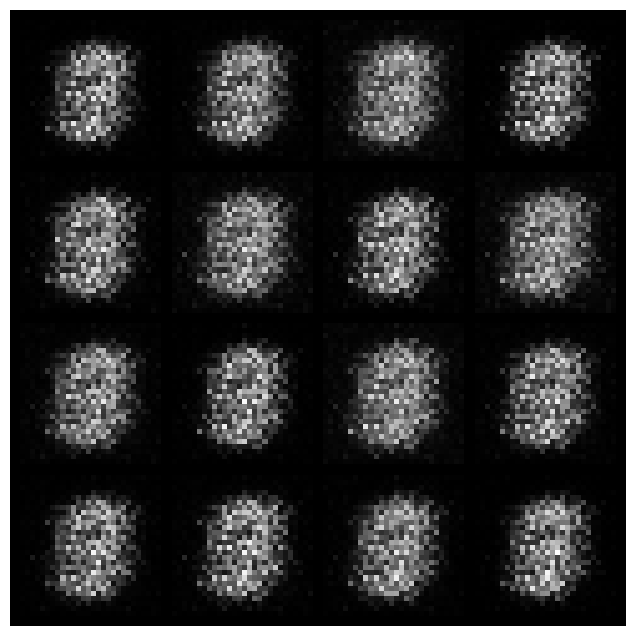

In [205]:
gan.visualize_generated_images(generator, device, shape=(4, 4), PATH=PLOT_PATH)